In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv("resultados.csv")

promedios = df.groupby(["tipo", "puntos", "dims", "hilos"])["tiempo_ms"].mean().reset_index()  # agrupa por columna y luego saca promedio de tiempo

serial   = promedios[promedios["tipo"] == "serial"][["puntos", "dims", "tiempo_ms"]].rename(columns={"tiempo_ms": "tiempo_serial"})  # filtra filas donde tipo = serial, descarta hilos, y renombra columna tiempo
paralelo = promedios[promedios["tipo"] == "paralelo"]  # aqui solo se queda con las filas donde tipo = paralelo

merged = paralelo.merge(serial, on=["puntos", "dims"])  # une ambas tablas usando puntos y dims como claves

base_1_hilo = merged[merged["hilos"] == 1][["puntos", "dims", "tiempo_ms"]].rename(columns={"tiempo_ms": "tiempo_1_hilo"})  # tomar solo las filas donde el paralelo corrio con 1 hilo 
merged = merged.merge(base_1_hilo, on=["puntos", "dims"])  # ahora cada fila del merged tiene tambien el tiempo base de 1 hilo para esa combinacion de puntos y dims
merged["speedup"] = merged["tiempo_1_hilo"] / merged["tiempo_ms"]  # calcula speedup y lo agrega en una columna nueva

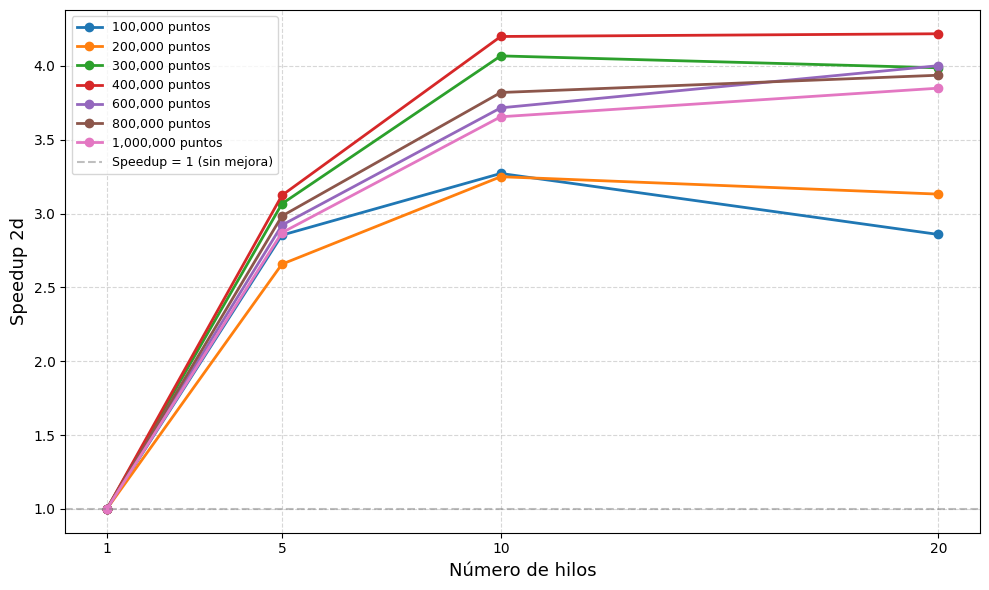

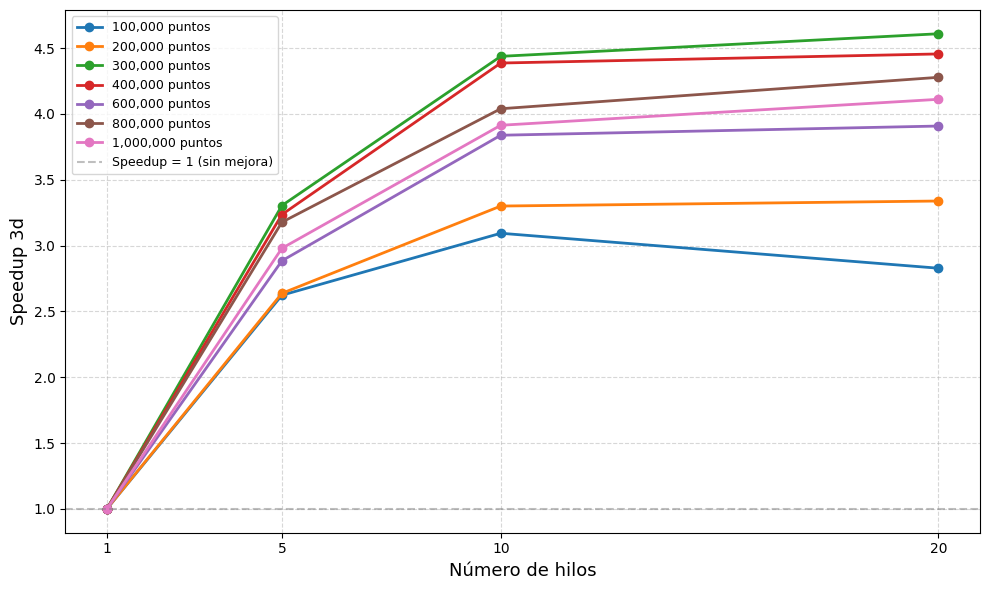

In [4]:
for dims in [2, 3]: # Una gráfica por dimensión
    subset = merged[merged["dims"] == dims]  # se queda con las filas de la dimensión en cuestión

    plt.figure(figsize=(10, 6))

    for n in sorted(subset["puntos"].unique()):  # obtiene los valores distintos de los puntos y los ordena. Itera sobre ellos
        data = subset[subset["puntos"] == n].sort_values("hilos")  # se queda solo con las filas del tamaño en cuestión y ordena la tabla por hilos
        plt.plot(data["hilos"], data["speedup"], marker="o", linewidth=2, label=f"{n:,} puntos")  # eje x = hilos, eje y = speedup

    # Línea de speedup ideal (lineal)
    plt.axhline(y=1, color="gray", linestyle="--", alpha=0.5, label="Speedup = 1 (sin mejora)")  # dibuja linea horizontal en y = 1 por referencia

    plt.xlabel("Número de hilos", fontsize=13)
    plt.ylabel(f"Speedup {dims}d", fontsize=13)
    plt.xticks([1, 5, 10, 20])  # fuerza que los ticks del eje x sean esos valores
    plt.legend(fontsize=9)
    plt.grid(True, linestyle="--", alpha=0.5)  # agrega cuadricula
    plt.tight_layout()
    plt.savefig(f"speedup_{dims}d.png", dpi=150)
    plt.show()
    plt.close()


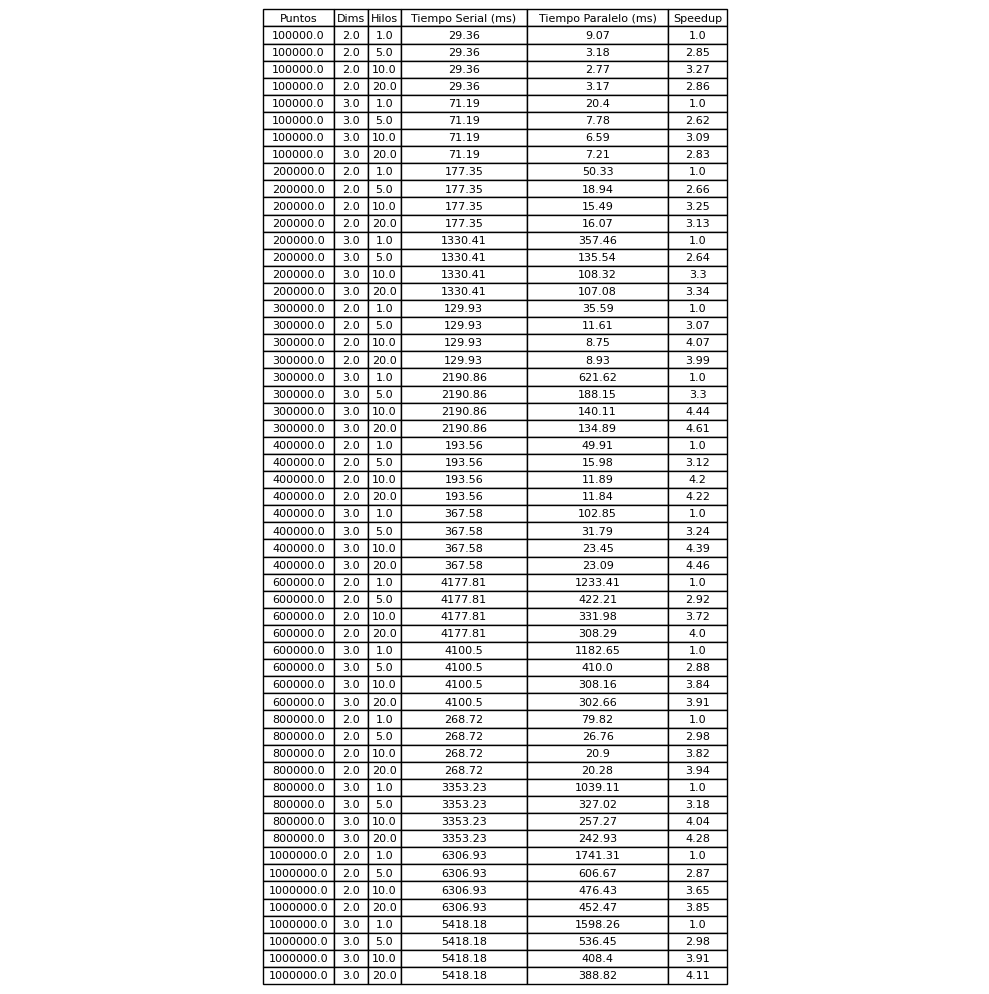

Tabla guardada: tabla_speedups.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.axis("off")

tabla_data = merged[["puntos", "dims", "hilos", "tiempo_serial", "tiempo_ms", "speedup"]].round(2)  # para la tabla toma ciertas columnas 

tabla = ax.table(  # crea el visual de la tabla
    cellText=tabla_data.values,  # usa los datos de la tabla
    colLabels=["Puntos", "Dims", "Hilos", "Tiempo Serial (ms)", "Tiempo Paralelo (ms)", "Speedup"],  # nombres de columnas
    cellLoc="center", # centra el contenido de las celdas
    loc="center"  # centra la tabla
)

tabla.auto_set_font_size(False)
tabla.set_fontsize(8)
tabla.auto_set_column_width(col=list(range(len(tabla_data.columns))))

plt.tight_layout()
plt.savefig("tabla_speedups.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

print("Tabla guardada: tabla_speedups.png")

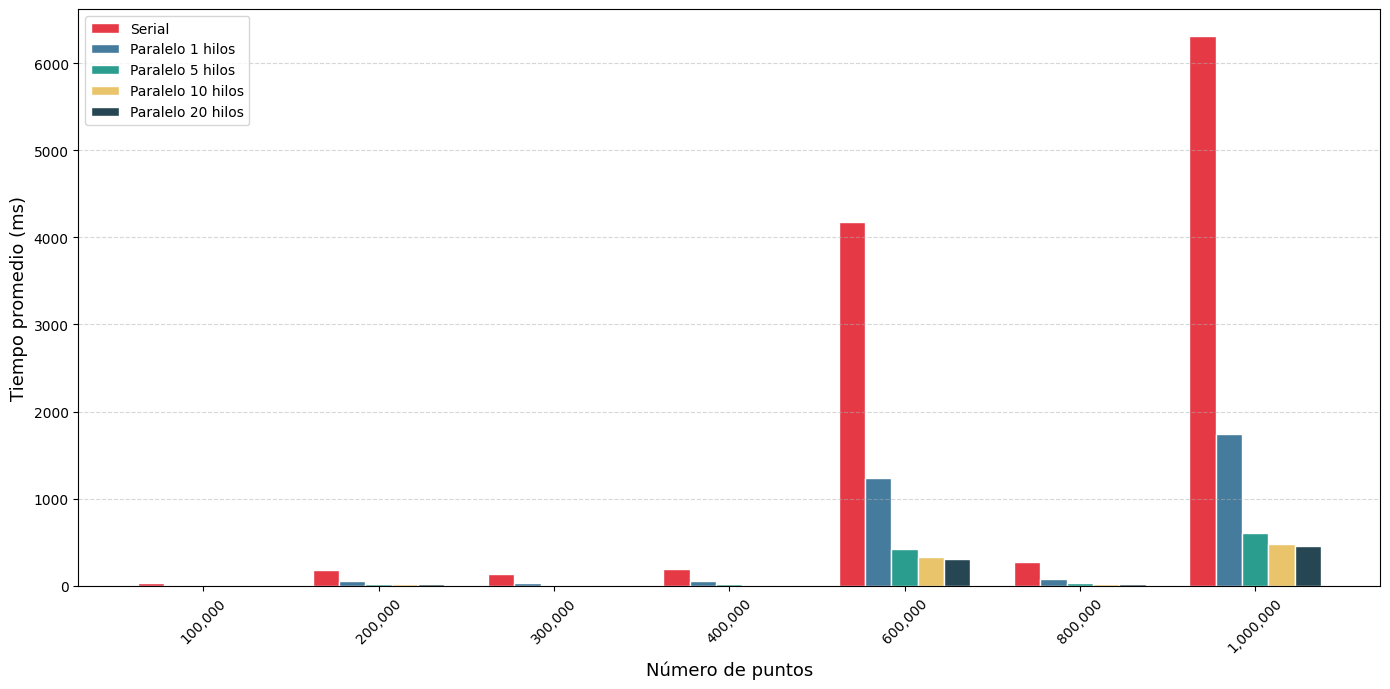

Gráfica guardada: tiempo_barras_2d.png


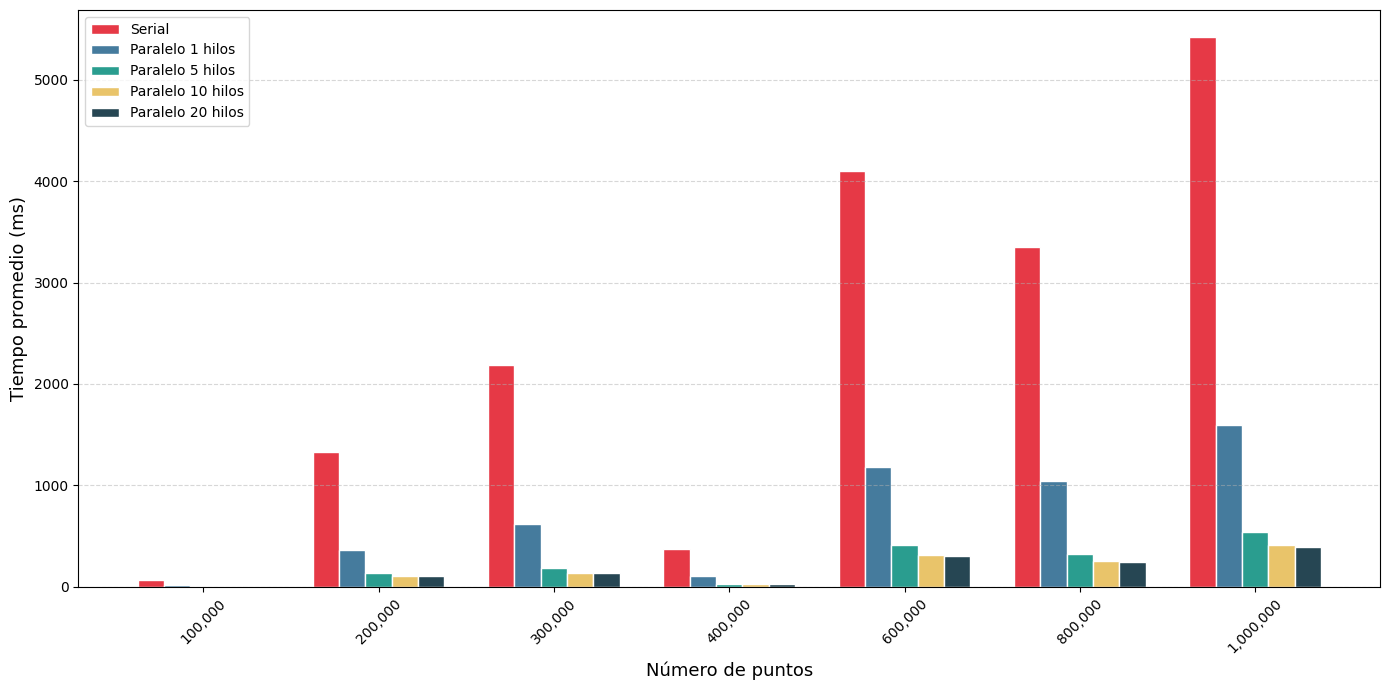

Gráfica guardada: tiempo_barras_3d.png


In [ ]:
def etiqueta(row):  # Recibe una fila y devuelve una etiqueta: "serial" si es serial, "paralelo n hilos" si es paralelo
    if row["tipo"] == "serial":
        return "Serial"
    return f"Paralelo {int(row['hilos'])} hilos"

promedios["linea"] = promedios.apply(etiqueta, axis=1)  # crea una nueva columna usando la función etiqueta 

orden = ["Serial", "Paralelo 1 hilos", "Paralelo 5 hilos", "Paralelo 10 hilos", "Paralelo 20 hilos"]
colores = {
    "Serial":            "#e63946",
    "Paralelo 1 hilos":  "#457b9d",
    "Paralelo 5 hilos":  "#2a9d8f",
    "Paralelo 10 hilos": "#e9c46a",
    "Paralelo 20 hilos": "#264653"
}

for dims in [2, 3]:  # separa por dimensión 
    subset = promedios[promedios["dims"] == dims]
    puntos = sorted(subset["puntos"].unique())

    x = np.arange(len(puntos))  # hace un arreglo con los diferente tamaños
    ancho = 0.15  # ancho de cada barra
    n_grupos = len(orden) # es = 5

    plt.figure(figsize=(14, 7))

    for i, nombre in enumerate(orden):
        data = subset[subset["linea"] == nombre].sort_values("puntos")  # filtra por valor de linea (ej. "paralelo 5 hilos") y ordena esas filas segun su tamaño
        if data.empty:
            continue
        offset = (i - n_grupos / 2) * ancho + ancho / 2  # esto calcula cuanto se debe mover horizontalmente cada barra para el visual
        plt.bar(x + offset, data["tiempo_ms"].values,  # dibuja grafica de barras con los tiempos
                width=ancho, label=nombre,
                color=colores[nombre], edgecolor="white")

    plt.xlabel("Número de puntos", fontsize=13)
    plt.ylabel("Tiempo promedio (ms)", fontsize=13)
    plt.xticks(x, [f"{p:,}" for p in puntos], rotation=45)
    plt.legend(fontsize=10)
    plt.grid(True, linestyle="--", alpha=0.5, axis="y")
    plt.tight_layout()
    plt.savefig(f"tiempo_barras_{dims}d.png", dpi=150)
    plt.show()
    plt.close()

    print(f"Gráfica guardada: tiempo_barras_{dims}d.png")